# Turbomaschinen - Studentenprojekt - Pumpenanalyse

### Bibliotheken laden

In [159]:
# pandas: Zum Laden und Verarbeiten der CSV-Datei
import pandas as pd

# numpy:** Für mathematische Berechnungen im Hintergrund
import numpy as np

# matplotlib: Zum Erstellen von Diagrammen
import matplotlib.pyplot as plt

# scipy: Für komplexe Statistik und Interpolation
from scipy.interpolate import interp1d

### CSV-Datei einlesen

In [160]:
# CSV-Datei einlesen und in einer Variablen speichern
volume_flow_data = pd.read_csv("volume_flow_data.csv")

# Textspalte 'Timestamp' in echtes Datumsformat umwandeln
volume_flow_data["Timestamp"] = pd.to_datetime(volume_flow_data["Timestamp"])

# Erste 5 Zeilen zur KOntrolle anzeigen
volume_flow_data.head()

,Timestamp,Volume Flow (m^3/h)
0,2024-04-01 00:00:00,312.54
1,2024-04-01 00:01:00,193.78
2,2024-04-01 00:02:00,393.96
3,2024-04-01 00:03:00,364.70
4,2024-04-01 00:04:00,100.33


### Physikalische Konstanten

In [161]:
# Vorgegebener Laufraddurchmesser (in mm)
d = 269

# Dichte der Pumpenflüssigkeit stammt aus dem gegebenen Pumpendatenblatt (in kg/m^3)
rho_fluid = 1033

# Die Erdbeschleunigung ist eine allgemeine physikalische Konstante (in m/s^2)
gravity = 9.81

# Motorwirkungsgrad stammt aus dem Pumpendatenblatt
efficiency_motor = 0.936

# Betriebspunkt des Volumenstroms ist durch Markierung aus dem Diagramm vom Pumpendatenblatt zu entnehmen (in m^3/h)
V_operating_point = 250

# Festlegung der Fenstergröße zur Glättung
window = 15

### Kennlinienpunkte aus Diagrammen vom Pumpendatenblatt S.3 ablesen (für Laufraddurchmesser 269mm) und Arrays erstellen

In [162]:
# Volumenstrom-Stützpunkte (in m^3/h)
flow_points = np.array([0, 100, 200, 300, 400, 500, 559])

# Zugehörige Förderhöhe H aus Diagramm 1 (in m)
head_points = np.array([23.5, 22.5, 21.0, 19.0, 16.5, 13.0, 10.0])

# Zugehöriger Wirkungsgrad eta aus dem Diagramm 3 (als Dezimalzahl)
efficiency_points = np.array([0.00, 0.41, 0.65, 0.76, 0.80, 0.70, 0.62])

# Zugehörige Leistungsaufnahme aus Diagramm 4 (in kW)
power_points = np.array([13.7, 15.3, 18.2, 21.0, 23.2, 24.8, 25.1])

### Interpolationsfunktionen erzeugen anhand der Arrays

In [163]:
# 'fill_value="extrapolate"' verhindert Abstürze bei Messwerten außerhalb des Diagrammbereichs

# Funktion für die Förderhöhe erzeugen
head_function = interp1d(flow_points, head_points, fill_value="extrapolate")

# Funktion für den Wirkungsgrad erzeugen
efficiency_function = interp1d(flow_points, efficiency_points, fill_value="extrapolate")

# Funktion für die Leistungsaufnahme erzeugen
power_function = interp1d(flow_points, power_points, fill_value="extrapolate")

### Berechnung der zeitspezifischen Betriebswerte (Basis für Aufgaben 1 bis 3)

In [164]:
# Es werden die zuvor erstellten Interpolationsfunktionen genutzt,
# um für jeden gemessenen Volumenstrom aus der CSV-Datei die exakten Pumpenwerte zu ermitteln

# Förderhöhe für jeden Messpunkt berechnen
volume_flow_data["Head_m"] = head_function(volume_flow_data["Volume Flow (m^3/h)"])

# Wirkungsgrad für jeden Messpunkt berechnen
volume_flow_data["Efficiency"] = efficiency_function(volume_flow_data["Volume Flow (m^3/h)"])

# Elektrische Leistungsaufnahme für jeden Messpunkt berechnen
volume_flow_data["P_welle_kW"] = power_function(volume_flow_data["Volume Flow (m^3/h)"])

# Gesamte elektrische Leistungsaufnahme inklusive Motor (in kW)
volume_flow_data["Electrical Power kW"] = volume_flow_data["P_welle_kW"] / efficiency_motor

# Erste Zeilen zur Kontrolle anzeigen lassen
volume_flow_data.head()

,Timestamp,Volume Flow (m^3/h),Head_m,Efficiency,P_welle_kW,Electrical Power kW
0,2024-04-01 00:00:00,312.54,18.68650,0.765016,21.27588,22.730641
1,2024-04-01 00:01:00,193.78,21.09330,0.635072,18.01962,19.251731
2,2024-04-01 00:02:00,393.96,16.65100,0.797584,23.06712,24.644359
3,2024-04-01 00:03:00,364.70,17.38250,0.785880,22.42340,23.956624
4,2024-04-01 00:04:00,100.33,22.49505,0.410792,15.30957,16.356378


### Hydraulische Nutzleistung und Wirkungsgrad berechnen (Vorbereitung zu Aufgabe 3)

In [165]:
# Umrechnung des Volumenstroms in m^3/s
volume_flow_data["Volume Flow m3s"] = volume_flow_data["Volume Flow (m^3/h)"] / 3600.0

# Berechnung der hydraulischen Leistung in kW (reine Nutzkraft, die im Wasser ankommt)
volume_flow_data["Hydraulic Power kW"] = (
    rho_fluid
    * gravity
    * volume_flow_data["Volume Flow m3s"]
    * volume_flow_data["Head_m"]
) / 1000.0 # Umrechnung in kW

# Verlustleistung berechnen (in kW)
volume_flow_data["P_verlust_kW"] = volume_flow_data["P_welle_kW"] - volume_flow_data ["Hydraulic Power kW"]
volume_flow_data["P_verlust_gesamt_kW"] = volume_flow_data["Electrical Power kW"] - volume_flow_data["Hydraulic Power kW"]

# Gesamtwirkungsgrad inklusive Motor berechnen
volume_flow_data["Total_Efficiency"] = volume_flow_data["Hydraulic Power kW"] / volume_flow_data["Electrical Power kW"]

### Zeitintervalle bestimmen (Notwendig für Integration/ Energieberechnung)

In [166]:
# Berechnung der genauen Zeitdifferenz in Sekunden zwischen den Messwerten
time_diffs_seconds = volume_flow_data["Timestamp"].diff().dt.total_seconds()
time_diffs_seconds = time_diffs_seconds.fillna(time_diffs_seconds.median()) # Ersten fehlenden Zeitabstand mit dem Median der Messintervalle auffüllen

#Umrechnung der Sekunden in Stunden
delta_t_hours = time_diffs_seconds / 3600.0

### Aufgabe 1: Berechnung des Energieverbrauchs

In [167]:
# Formel: Energie (kWh) = Summe von allen Messpunkten (mit Leistung in kW * Zeitdauer in h) -> Gesamtenergieverbrauch
shaft_energy = (volume_flow_data["P_welle_kW"] * delta_t_hours).sum()
electrical_energy = (volume_flow_data["Electrical Power kW"] * delta_t_hours).sum()

### Aufgabe 2: Ermitteln des durchschnittlichen Pumpenwirkungsgrads

In [168]:
# Bildung des arithmetischen Mittelwertes aller Wirkungsgrade
# Zur Umrechnung in % wird mit 100 multipliziert
average_efficiency = volume_flow_data["Efficiency"].mean() * 100
average_total_efficiency = volume_flow_data["Total_Efficiency"].mean() * 100

### Aufgabe 3: Berechnung der ungenutzten Energie

In [169]:
# Sinnvoll genutzte hydraulische Energie über den Zeitraum aufsummieren
hydraulic_energy = (volume_flow_data["Hydraulic Power kW"] * delta_t_hours).sum()

# Ungenutzte Energie = Aufgewendete Energie - genutzte Energie
loss_energy_pump = shaft_energy - hydraulic_energy
loss_energy_total = electrical_energy - hydraulic_energy

### Wirtschaftlichkeitsanalyse & Betriebspunkt-Auswertung

In [170]:
# Berechnung der finanziellen Verluste
loss_costs = loss_energy_total * electricity_price

# Ermittlung des Best Efficiency Points (BEP) aus den Stützstellen
best_efficiency = np.max(efficiency_points) * 100
bep_flow = flow_points[np.argmax(efficiency_points)]

# Berechnung des absoluten Abstands zum optimalen Betriebspunkt für jeden Datenpunkt
volume_flow_data["Distance_to_BEP"] = abs(volume_flow_data["Volume Flow (m^3/h)"] - bep_flow)

### Glättung der Daten

In [171]:
volume_flow_data["Volume_Flow_smooth"] = volume_flow_data["Volume Flow (m^3/h)"].rolling(window, center=True, min_periods=1).mean()
volume_flow_data["Head_smooth"] = volume_flow_data["Head_m"].rolling(window, center=True, min_periods=1).mean()
volume_flow_data["P_welle_smooth"] = volume_flow_data["P_welle_kW"].rolling(window, center=True, min_periods=1).mean()
volume_flow_data["Electrical_Power_smooth"] = volume_flow_data["Electrical Power kW"].rolling(window, center=True, min_periods=1).mean()
volume_flow_data["Hydraulic_Power_smooth"] = volume_flow_data["Hydraulic Power kW"].rolling(window, center=True, min_periods=1).mean()
volume_flow_data["P_verlust_smooth"] = volume_flow_data["P_verlust_kW"].rolling(window, center=True, min_periods=1).mean()
volume_flow_data["P_verlust_gesamt_smooth"] = volume_flow_data["P_verlust_gesamt_kW"].rolling(window, center=True, min_periods=1).mean()
volume_flow_data["Efficiency_smooth"] = volume_flow_data["Efficiency"].rolling(window, center=True, min_periods=1).mean()

### Formatierte Ausgabe der Ergebnisse für das Protokoll

In [172]:
print("==================================================")
print("           ERGEBNISSE DER PUMPENANALYSE           ")
print("==================================================")

print(f"Gegebener Laufraddurchmesser und entsprechende Kennlinie aus Pumpendatenblatt: {d} mm")

print(f"Messzeitraum: {volume_flow_data['Timestamp'].min()} bis {volume_flow_data['Timestamp'].max()}")

print()

print(f"Mittlerer Volumenstrom: {volume_flow_data['Volume Flow (m^3/h)'].mean():.2f} m³/h")

print(f"Mittlere Förderhöhe: {volume_flow_data['Head_m'].mean():.2f} m")

print()

print(f"Lösung Aufgabe 1: Elektrischer Energieverbrauch: {electrical_energy:.2f} kWh")

print(f"Energieverbrauch an der Pumpenwelle: {shaft_energy:.2f} kWh")

print ()

print(f"Lösung Aufgabe 2: Durchschnitts-Wirkungsgrad: {average_efficiency:.2f} %")

print(f"Durchschnittlicher Gesamtwirkungsgrad (inkl. Motor): {average_total_efficiency:.2f} %")

print()

print(f"Lösung Aufgabe 3: Sinnvoll genutzte Energie: {hydraulic_energy:.2f} kWh")

print(f"Ungenutzte Energie (Verlust): {loss_energy:.2f} kWh")

print(f"Ungenutzte Energie (Gesamtverlust inkl. Motor): {loss_energy_total:.2f} kWh")

print()

print(f"Finanzielle Verluste im Betrieb: {loss_costs:.2f} €")

print(f"Bester Wirkungsgrad (BEP) bei: {bep_flow} m³/h ({best_efficiency:.1f}%)")

print("==================================================\n")

           ERGEBNISSE DER PUMPENANALYSE           
Gegebener Laufraddurchmesser und entsprechende Kennlinie aus Pumpendatenblatt: 269 mm
Messzeitraum: 2024-04-01 00:00:00 bis 2024-04-01 23:59:00

Mittlerer Volumenstrom: 253.39 m³/h
Mittlere Förderhöhe: 19.76 m

Lösung Aufgabe 1: Elektrischer Energieverbrauch: 501.82 kWh
Energieverbrauch an der Pumpenwelle: 469.70 kWh

Lösung Aufgabe 2: Durchschnitts-Wirkungsgrad: 67.53 %
Durchschnittlicher Gesamtwirkungsgrad (inkl. Motor): 64.15 %

Lösung Aufgabe 3: Sinnvoll genutzte Energie: 327.95 kWh
Ungenutzte Energie (Verlust): 141.75 kWh
Ungenutzte Energie (Gesamtverlust inkl. Motor): 173.87 kWh

Finanzielle Verluste im Betrieb: 60.85 €
Bester Wirkungsgrad (BEP) bei: 400 m³/h (80.0%)



### Aufgabe 4: Erstellung zusätzlicher Analysen/ Visualisierungen

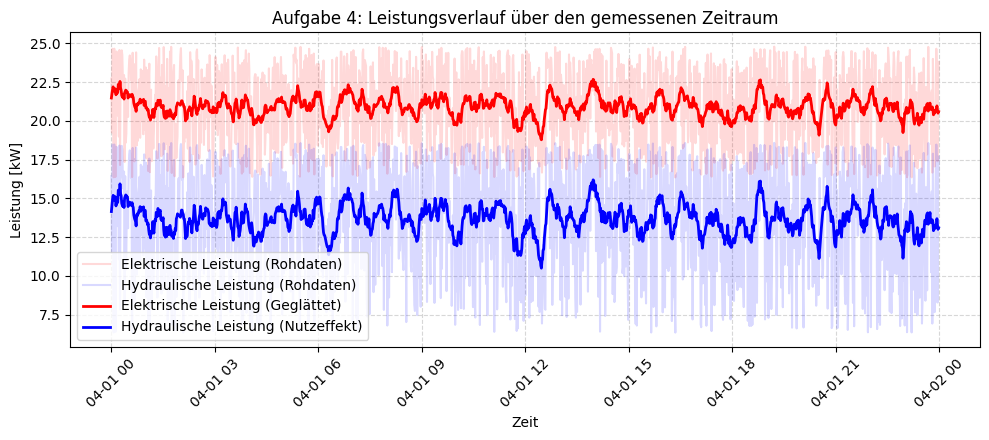

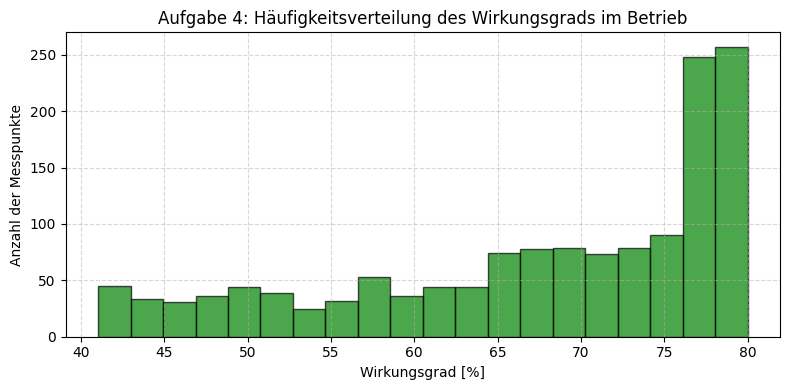

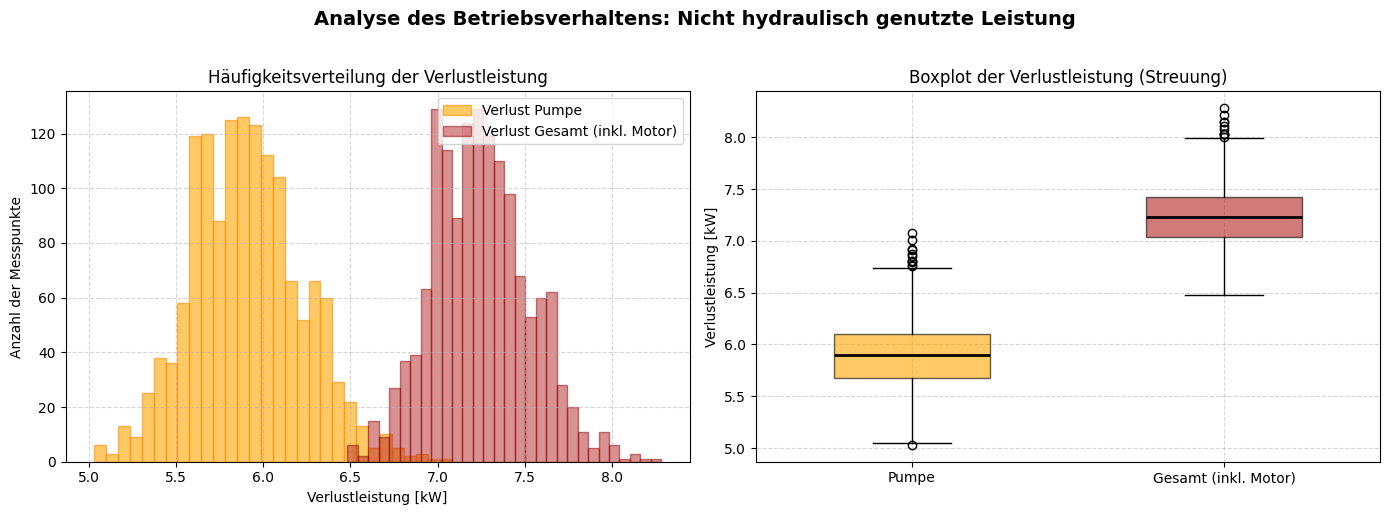

In [173]:
# Diagramm A: Leistung vs. Zeit (Vergleich von Aufnahme zu Nutzen)
plt.figure(figsize=(10, 4.5))

# Rohdaten im Hintergrund
plt.plot(volume_flow_data["Timestamp"], volume_flow_data["Electrical Power kW"], color='red', alpha=0.15, label='Elektrische Leistung (Rohdaten)')
plt.plot(volume_flow_data["Timestamp"], volume_flow_data["Hydraulic Power kW"], color='blue', alpha=0.15, label='Hydraulische Leistung (Rohdaten)')

# Geglättete Kurven im Vordergrund
plt.plot(volume_flow_data["Timestamp"], volume_flow_data["Electrical_Power_smooth"], color='red', linewidth=2, label='Elektrische Leistung (Geglättet)')
plt.plot(volume_flow_data["Timestamp"], volume_flow_data["Hydraulic_Power_smooth"], color='blue', linewidth=2, label='Hydraulische Leistung (Nutzeffekt)')

plt.title("Aufgabe 4: Leistungsverlauf über den gemessenen Zeitraum")
plt.xlabel("Zeit")
plt.ylabel("Leistung [kW]")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Diagramm B: Histogramm zur Verteilung des Wirkungsgrads im Betrieb
plt.figure(figsize=(8, 4))
plt.hist(volume_flow_data["Efficiency"] * 100, bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title("Aufgabe 4: Häufigkeitsverteilung des Wirkungsgrads im Betrieb")
plt.xlabel("Wirkungsgrad [%]")
plt.ylabel("Anzahl der Messpunkte")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Diagramm C: Analyse Betriebsverhalten

# Erstellt ein kombiniertes Diagramm (1 Zeile, 2 Spalten)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linkes Diagramm: Histogramm der Verlustleistungen
ax1.hist(
    volume_flow_data["P_verlust_smooth"], 
    bins=30, 
    alpha=0.6, 
    color='orange', 
    edgecolor='darkorange', 
    label='Verlust Pumpe'
)
ax1.hist(
    volume_flow_data["P_verlust_gesamt_smooth"], 
    bins=30, 
    alpha=0.5, 
    color='firebrick', 
    edgecolor='darkred', 
    label='Verlust Gesamt (inkl. Motor)'
)
ax1.set_title("Häufigkeitsverteilung der Verlustleistung")
ax1.set_xlabel("Verlustleistung [kW]")
ax1.set_ylabel("Anzahl der Messpunkte")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Rechtes Diagramm: Boxplot der Verlustleistungen
# Übergabe der Daten als Liste für den Boxplot
boxplot_data = [
    volume_flow_data["P_verlust_smooth"].dropna(), 
    volume_flow_data["P_verlust_gesamt_smooth"].dropna()
]

# Erstellung des Boxplots mit angepassten Labels
box = ax2.boxplot(
    boxplot_data, 
    patch_artist=True, 
    tick_labels=['Pumpe', 'Gesamt (inkl. Motor)'],
    widths=0.5
)

# Farben der Boxen an das linke Diagramm anpassen
colors = ['orange', 'firebrick']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Median-Linien im Boxplot deutlicher hervorheben
for median in box['medians']:
    median.set(color='black', linewidth=2)

ax2.set_title("Boxplot der Verlustleistung (Streuung)")
ax2.set_ylabel("Verlustleistung [kW]")
ax2.grid(True, linestyle='--', alpha=0.5)

# Layout optimieren und Diagramm anzeigen
plt.suptitle("Analyse des Betriebsverhaltens: Nicht hydraulisch genutzte Leistung", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()